In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style("whitegrid")

print("Day 4 libraries imported successfully!")

Day 4 libraries imported successfully!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style("whitegrid")

print("Day 4 libraries imported successfully!")

Day 4 libraries imported successfully!


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style("whitegrid")

print("Day 4 libraries imported successfully!")

Day 4 libraries imported successfully!


In [28]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

print(nav_df.head())
print(nav_df.columns)
print(nav_df.shape)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='str')
(46000, 3)


In [29]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code","date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_df.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [30]:
pd.to_datetime()

TypeError: to_datetime() missing 1 required positional argument: 'arg'

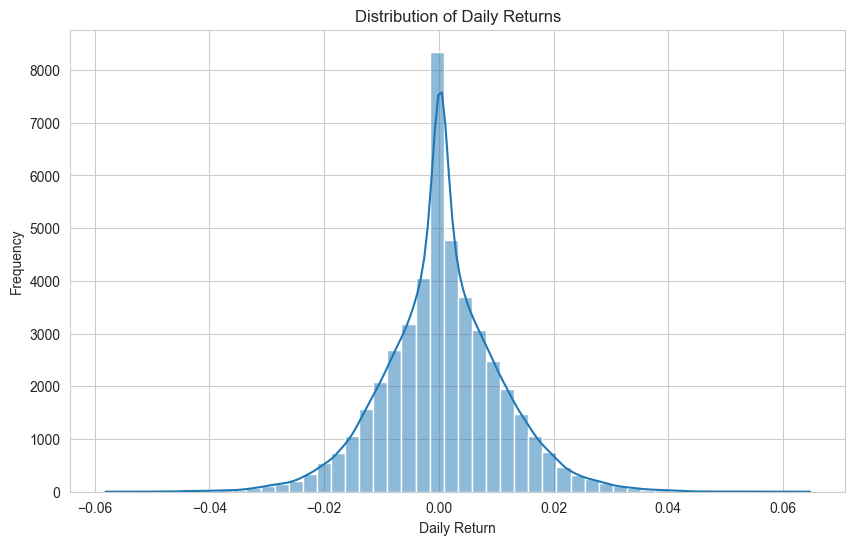

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [ ]:
print(nav_df["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [ ]:
cagr_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[nav_df["amfi_code"] == fund]

    fund_df = fund_df.sort_values("date")

    start_nav = fund_df["nav"].iloc[0]
    end_nav = fund_df["nav"].iloc[-1]

    years = (
        (fund_df["date"].iloc[-1] - fund_df["date"].iloc[0]).days
        / 365
    )

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_list.append({
        "amfi_code": fund,
        "CAGR": cagr
    })

cagr_df = pd.DataFrame(cagr_list)

print(cagr_df.head())

   amfi_code      CAGR
0     100016  0.026352
1     100025  0.044551
2     100033  0.300997
3     101206  0.235205
4     101207  0.079331


In [ ]:
cagr_df

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331
5,101208,0.065044
6,102885,0.182188
7,102886,0.011709
8,102887,0.168287
9,118632,0.240312


In [ ]:
cagr_df = cagr_df.sort_values(
    by="CAGR",
    ascending=False
)

print(cagr_df.head(10))

    amfi_code      CAGR
25     120505  0.328016
21     119598  0.323981
39     149324  0.322621
36     148569  0.319245
34     148567  0.309499
30     120843  0.308833
2      100033  0.300997
38     149323  0.295581
16     119094  0.281926
19     119551  0.257849


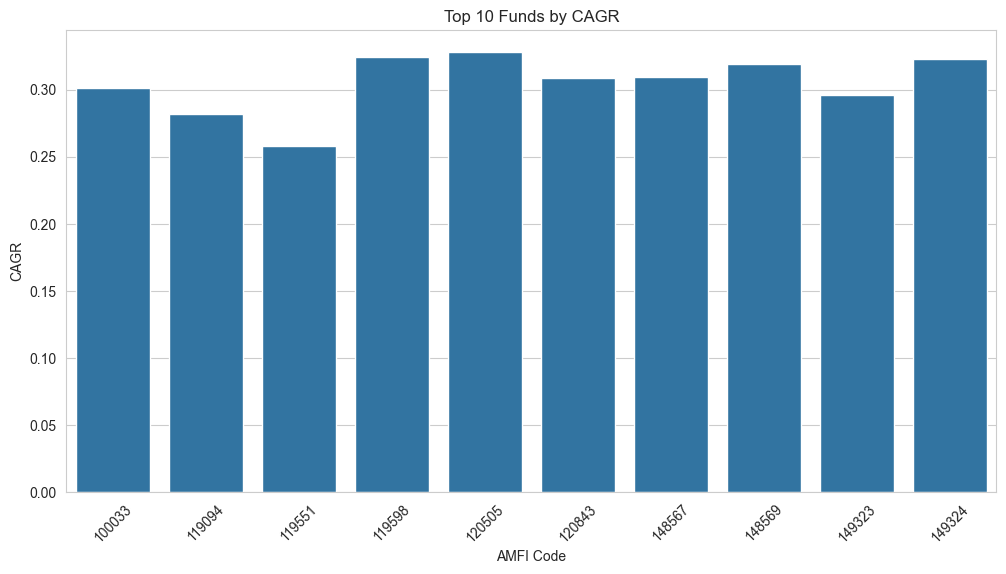

In [ ]:
top10 = cagr_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="CAGR"
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR")

plt.xticks(rotation=45)

plt.show()

In [ ]:
rf = 0.065

sharpe_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[nav_df["amfi_code"] == fund]

    mean_return = fund_df["daily_return"].mean()

    std_return = fund_df["daily_return"].std()

    sharpe_ratio = ((mean_return * 252) - rf) / (std_return * np.sqrt(252))

    sharpe_list.append({
        "amfi_code": fund,
        "Sharpe_Ratio": sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_list)

print(sharpe_df.head())

   amfi_code  Sharpe_Ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661


In [ ]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

print(sharpe_df.head(10))

    amfi_code  Sharpe_Ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101
38     149323      1.132122
2      100033      1.093699
9      118632      1.081659
3      101206      1.027213
24     120504      1.026524


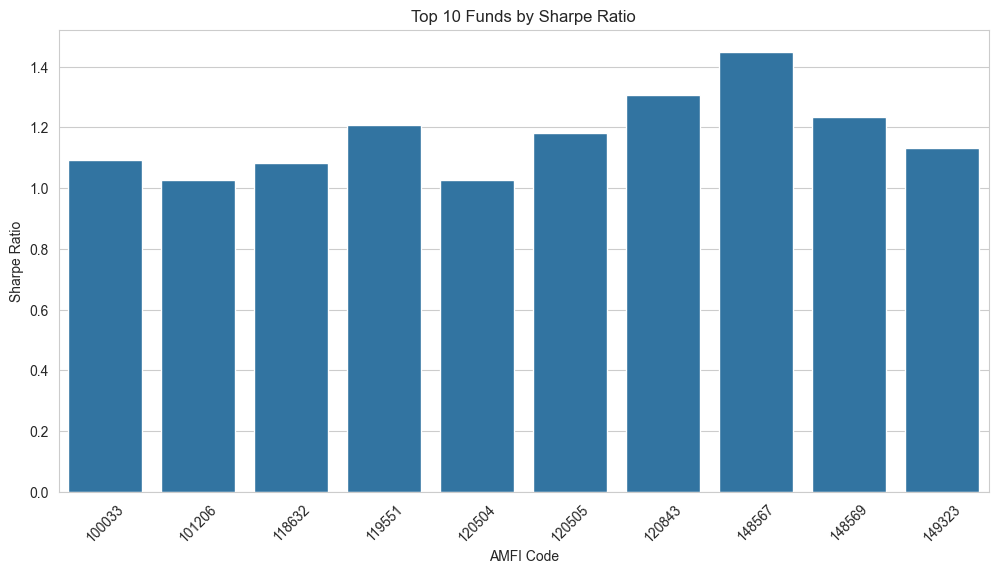

In [ ]:
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="amfi_code",
    y="Sharpe_Ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()

In [ ]:
sortino_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[nav_df["amfi_code"] == fund]

    mean_return = fund_df["daily_return"].mean()

    downside_returns = fund_df.loc[
        fund_df["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    sortino_ratio = ((mean_return * 252) - rf) / (downside_std * np.sqrt(252))

    sortino_list.append({
        "amfi_code": fund,
        "Sortino_Ratio": sortino_ratio
    })

sortino_df = pd.DataFrame(sortino_list)

print(sortino_df.head())

   amfi_code  Sortino_Ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644


In [ ]:
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

print(sortino_df.head(10))

    amfi_code  Sortino_Ratio
34     148567       2.385644
30     120843       2.364320
36     148569       2.146914
19     119551       2.140267
25     120505       2.029353
38     149323       1.875101
9      118632       1.850133
2      100033       1.829134
24     120504       1.805294
3      101206       1.799563


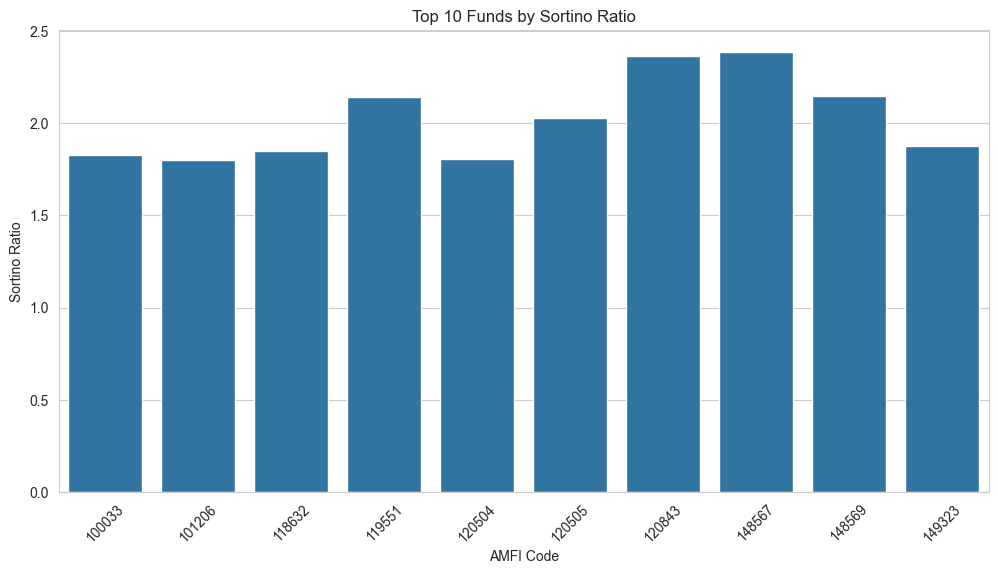

In [ ]:
top10_sortino = sortino_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x="amfi_code",
    y="Sortino_Ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.show()

In [ ]:
drawdown_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[nav_df["amfi_code"] == fund].copy()

    fund_df["running_max"] = fund_df["nav"].cummax()

    fund_df["drawdown"] = (
        fund_df["nav"] /
        fund_df["running_max"]
    ) - 1

    max_drawdown = fund_df["drawdown"].min()

    drawdown_list.append({
        "amfi_code": fund,
        "Max_Drawdown": max_drawdown
    })

drawdown_df = pd.DataFrame(drawdown_list)

print(drawdown_df.head())

   amfi_code  Max_Drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [ ]:
drawdown_df = drawdown_df.sort_values(
    by="Max_Drawdown",
    ascending=False
)

print(drawdown_df.head(10))

    amfi_code  Max_Drawdown
27     120507     -0.000977
31     120844     -0.001163
5      101208     -0.001622
1      100025     -0.043083
18     119120     -0.043287
13     118636     -0.083164
6      102885     -0.108599
34     148567     -0.112657
3      101206     -0.112916
12     118635     -0.116506


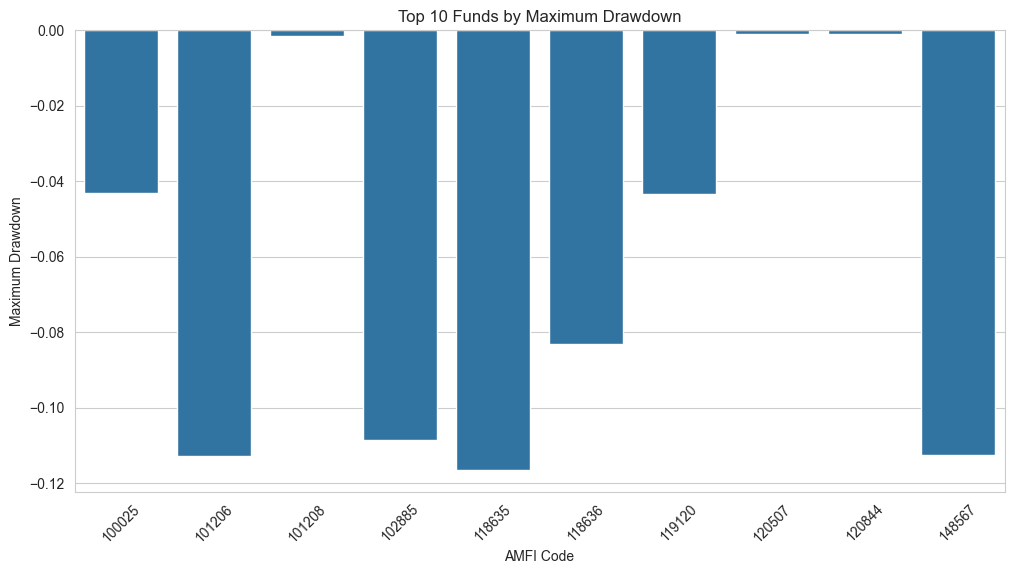

In [ ]:
top10_drawdown = drawdown_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_drawdown,
    x="amfi_code",
    y="Max_Drawdown"
)

plt.title("Top 10 Funds by Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)

plt.show()

In [ ]:
scorecard_df = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
).merge(
    sortino_df,
    on="amfi_code"
).merge(
    drawdown_df,
    on="amfi_code"
)

print(scorecard_df.head())

   amfi_code      CAGR  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown
0     120505  0.328016      1.180101       2.029353     -0.181885
1     119598  0.323981      0.945308       1.675317     -0.287060
2     149324  0.322621      0.949796       1.619793     -0.311719
3     148569  0.319245      1.234930       2.146914     -0.163967
4     148567  0.309499      1.448291       2.385644     -0.112657


In [ ]:
scorecard_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [ ]:
scorecard_df["Overall_Score"] = (
    scorecard_df["CAGR"].rank(ascending=False)
    + scorecard_df["Sharpe_Ratio"].rank(ascending=False)
    + scorecard_df["Sortino_Ratio"].rank(ascending=False)
    + scorecard_df["Max_Drawdown"].rank(ascending=False)
)

scorecard_df = scorecard_df.sort_values(
    by="Overall_Score"
)

print(scorecard_df.head(10))

    amfi_code      CAGR  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown  \
4      148567  0.309499      1.448291       2.385644     -0.112657   
5      120843  0.308833      1.306744       2.364320     -0.129740   
3      148569  0.319245      1.234930       2.146914     -0.163967   
9      119551  0.257849      1.208267       2.140267     -0.150124   
0      120505  0.328016      1.180101       2.029353     -0.181885   
11     101206  0.235205      1.027213       1.799563     -0.112916   
6      100033  0.300997      1.093699       1.829134     -0.162172   
7      149323  0.295581      1.132122       1.875101     -0.172481   
12     120504  0.232774      1.026524       1.805294     -0.125883   
10     118632  0.240312      1.081659       1.850133     -0.174141   

    Overall_Score  
4            15.0  
5            23.0  
3            31.0  
9            35.0  
0            36.0  
11           40.0  
6            42.0  
7            42.0  
12           44.0  
10           49.0  


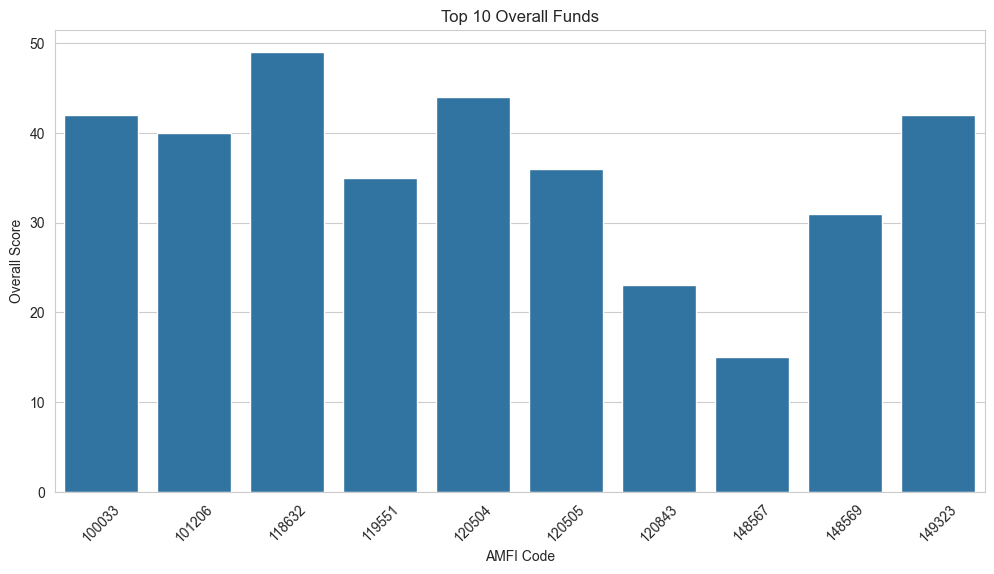

In [ ]:
top10_score = scorecard_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_score,
    x="amfi_code",
    y="Overall_Score"
)

plt.title("Top 10 Overall Funds")
plt.xlabel("AMFI Code")
plt.ylabel("Overall Score")

plt.xticks(rotation=45)

plt.show()

In [ ]:
benchmark_returns = (
    nav_df.groupby("date")["daily_return"]
    .mean()
    .reset_index()
)

benchmark_returns.rename(
    columns={"daily_return": "benchmark_return"},
    inplace=True
)

print(benchmark_returns.head())

        date  benchmark_return
0 2022-01-03               NaN
1 2022-01-04         -0.001451
2 2022-01-05          0.001977
3 2022-01-06          0.000341
4 2022-01-07          0.000627


In [ ]:
alpha_beta_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[nav_df["amfi_code"] == fund][
        ["date", "daily_return"]
    ]

    merged_df = fund_df.merge(
        benchmark_returns,
        on="date"
    ).dropna()

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged_df["benchmark_return"],
        merged_df["daily_return"]
    )

    alpha_beta_list.append({
        "amfi_code": fund,
        "Alpha": intercept,
        "Beta": slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

print(alpha_beta_df.head())

   amfi_code     Alpha      Beta
0     100016 -0.000356  0.788441
1     100025  0.000132  0.060713
2     100033  0.000454  0.991590
3     101206  0.000387  0.737015
4     101207 -0.001392  2.878184


In [ ]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


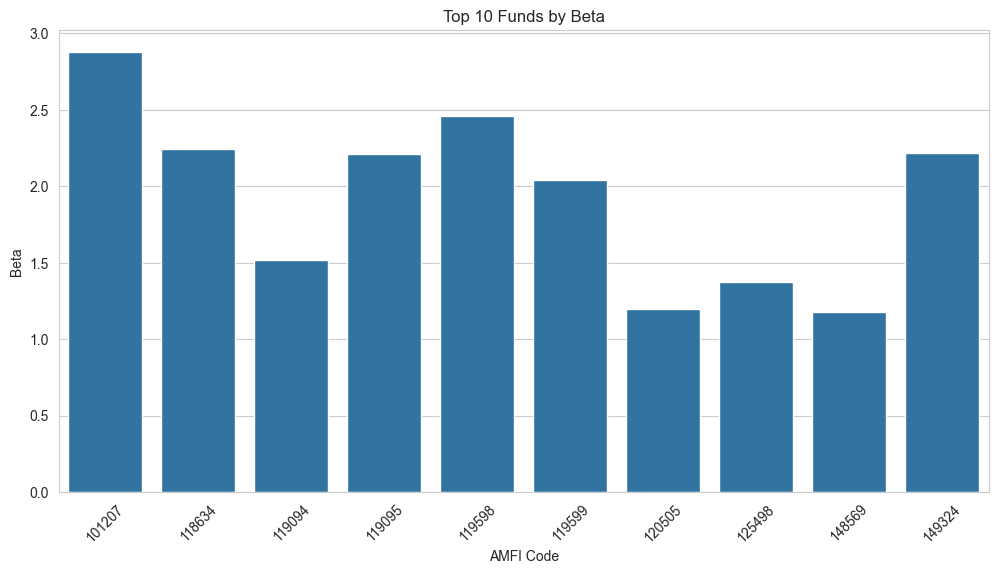

In [ ]:
top_beta = alpha_beta_df.sort_values(
    by="Beta",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_beta,
    x="amfi_code",
    y="Beta"
)

plt.title("Top 10 Funds by Beta")
plt.xlabel("AMFI Code")
plt.ylabel("Beta")

plt.xticks(rotation=45)

plt.show()

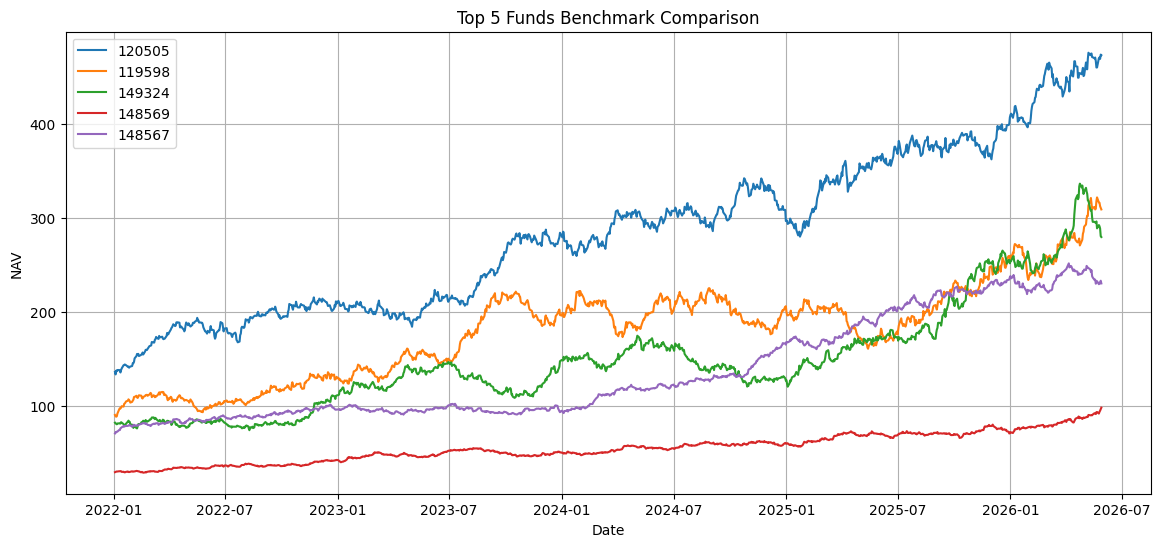

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("..") / "data" / "processed"

scorecard_df = pd.read_csv(BASE / "fund_scorecard.csv")
nav_df = pd.read_csv(BASE / "02_nav_history_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

top5_funds = scorecard_df.head(5)["amfi_code"]

plt.figure(figsize=(14, 6))

for fund in top5_funds:
    fund_data = nav_df[nav_df["amfi_code"] == fund]
    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.title("Top 5 Funds Benchmark Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.savefig("benchmark_comparison_chart.png", dpi=300, bbox_inches="tight")
plt.show()